<class 'pandas.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Month   108 non-null    datetime64[us]
 1   Sales   108 non-null    int64         
dtypes: datetime64[us](1), int64(1)
memory usage: 1.8 KB


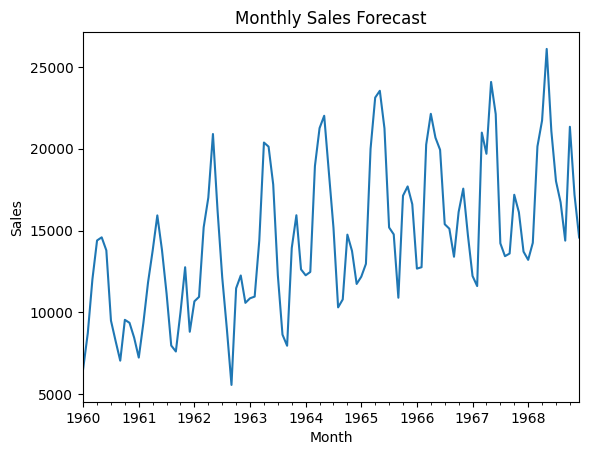

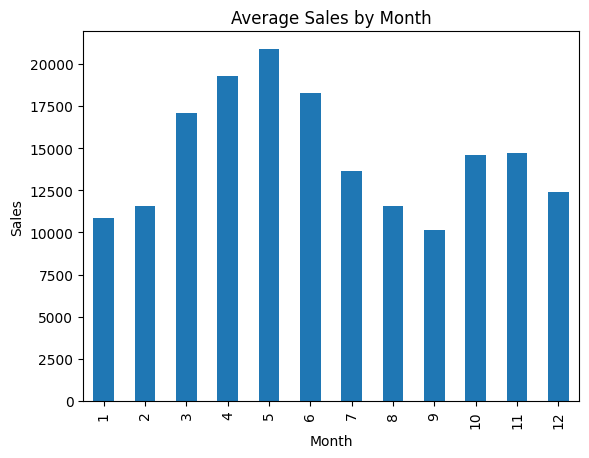

        Month  Sales  month_num  year    lag_1    lag_2
12 1961-01-01   7237          1  1961   8456.0   6550.0
13 1961-02-01   9374          2  1961   7237.0   8728.0
14 1961-03-01  11837          3  1961   9374.0  12026.0
15 1961-04-01  13784          4  1961  11837.0  14395.0
16 1961-05-01  15926          5  1961  13784.0  14587.0
R2 Score: 0.7750365968579772


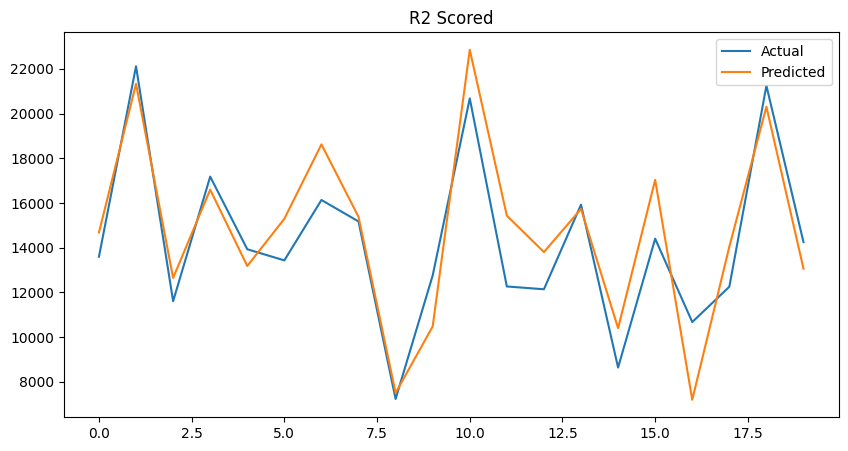

Database Saved!
                 Month  Sales
0  1968-05-01 00:00:00  26099
1  1967-05-01 00:00:00  24081
2  1965-05-01 00:00:00  23541
3  1965-04-01 00:00:00  23125
4  1966-04-01 00:00:00  22135


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import sqlite3



url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-car-sales.csv"
df = pd.read_csv(url)
df.head()


df["Month"] = pd.to_datetime(df["Month"])
df.info()

df.isnull().sum()

df.describe()

df.set_index("Month")["Sales"].plot(kind="line")
plt.title("Monthly Sales Forecast")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

df['month_num'] = df['Month'].dt.month
monthly_avg = df.groupby("month_num")["Sales"].mean()
monthly_avg.plot(kind="bar")
plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

df["year"] = df["Month"].dt.year
df["month_num"] = df["Month"].dt.month
df["lag_1"] = df["Sales"].shift(1)
df["lag_2"] = df["Sales"].shift(12)

df = df.dropna()
print(df.head())

X = df[["year", "month_num", "lag_1", "lag_2"]]
y = df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor()
model.fit(X_train, y_train)

predictions = model.predict(X_test)
score = r2_score(y_test, predictions)
print(f"R2 Score: {score}")

plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label="Actual")
plt.plot(predictions, label="Predicted")
plt.title("R2 Scored")
plt.legend()
plt.show()


conn = sqlite3.connect("sales.db")
df.to_sql("sales", conn, if_exists="replace", index=False)
print("Database Saved!")

query = """
SELECT Month, Sales
FROM Sales
ORDER BY Sales DESC
LIMIT 5
"""
result = pd.read_sql(query, conn)
print(result)


## Model Limitations
The model slightly overestimates peak months spring,
suggesting it over-learned seasonal patterns from training data.
Future improvements could include regularization techniques
to reduce this overestimation bias.

## Conclusions
1. Car sales show strong upward trend from 1960-1968
2. Spring April-May consistently drives peak sales
3. Random Forest model achieved R2=0.78 explains 78% of variation
4. Peak month: May 1968 with 26,099 cars sold
5. Seasonal patterns and lag features were key predictors

## Sales Trend Analysis
Monthly car sales show a clear upward trend from 1960-1968,
with peak sales in 1968. Strong seasonal patterns are visible,
with sales typically peaking mid-year and dropping in winter months.

## Seasonal Patterns
May and April consistently show the highest average car sales,
confirming spring as peak buying season — likely driven by
tax refunds, post-winter purchases, and favorable weather.
December and January show the lowest sales.


## Sales Forecasting Model
Random Forest Regressor achieved R2 score of 0.78,
meaning the model explains 78% of sales variation.
Key features: year trend, month seasonality, and
lag features previous month sales.